# Notebook 3: Train MobileNetV2 at One Resolution

This is the core experimental notebook. Running it FOUR TIMES, once for each target resolution (64, 128, 224, 384). Changing the `TARGET_RESOLUTION` in section 3.1 between runs.

The notebook:
1. Loads the 384×384 preprocessed images
2. Resizes them on-the-fly to `TARGET_RESOLUTION`
3. Trains MobileNetV2 with ImageNet-pretrained weights
4. Evaluates on the test set
5. Records training time, accuracy, F1, and (if available) GPU memory used
6. Saves the trained model and metrics to a per-resolution results folder

**Inputs:** `processed/train,val,test` from Notebook 2
**Outputs:** `results/res_<RESOLUTION>/` containing model, metrics, predictions


## 3.1 Configuration — CHANGE THIS BETWEEN RUNS

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# ============================================================
# CHANGE THIS BETWEEN RUNS: 64, 128, 224, or 384
TARGET_RESOLUTION = 384
# ============================================================

# Fixed across runs
EPOCHS = 15
BATCH_SIZE = 16 # Reduced batch size to mitigate memory issues
LEARNING_RATE = 1e-3
SEED = 42

# Paths
from pathlib import Path
PROCESSED_FOLDER = Path('/content/drive/MyDrive/VisionProject')
RESULTS_BASE = Path('/content/drive/MyDrive/VisionProject')

RESULTS_DIR = RESULTS_BASE / f"res_{TARGET_RESOLUTION}"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print(f"=== Training at {TARGET_RESOLUTION} x {TARGET_RESOLUTION} ===")
print(f"Epochs: {EPOCHS}, Batch: {BATCH_SIZE}, LR: {LEARNING_RATE}")
print(f"Results will be saved to: {RESULTS_DIR}")

=== Training at 384 x 384 ===
Epochs: 15, Batch: 16, LR: 0.001
Results will be saved to: /content/drive/MyDrive/VisionProject/res_384


## 3.2 Imports And Reproducibility

In [3]:
import os
import time
import json
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, classification_report, confusion_matrix)
import matplotlib.pyplot as plt

# Reproducibility
tf.keras.utils.set_random_seed(SEED)
np.random.seed(SEED)

# Check GPU
print("TF version:", tf.__version__)
gpus = tf.config.list_physical_devices("GPU")
print(f"GPUs available: {len(gpus)}")
if gpus:
    for gpu in gpus:
        print(f"  {gpu}")
    # Enable memory growth (avoid pre-allocating all GPU memory)
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError as e:
        print("Note:", e)

TF version: 2.20.0
GPUs available: 1
  PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')


## 3.3 Load Datasets At Target Resolution

In [4]:
IMG_SIZE = (TARGET_RESOLUTION, TARGET_RESOLUTION)

# Load with on-the-fly resize from 384 -> TARGET_RESOLUTION
train_ds = tf.keras.utils.image_dataset_from_directory(
    PROCESSED_FOLDER / "train",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    color_mode="rgb",
    shuffle=True,
    seed=SEED
)
val_ds = tf.keras.utils.image_dataset_from_directory(
    PROCESSED_FOLDER / "val",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    color_mode="rgb",
    shuffle=False
)
test_ds = tf.keras.utils.image_dataset_from_directory(
    PROCESSED_FOLDER / "test",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    color_mode="rgb",
    shuffle=False
)

class_names = train_ds.class_names
num_classes = len(class_names)
print(f"\nClasses: {num_classes}")
print(f"Class names: {class_names}")

# Cache + prefetch
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)
test_ds = test_ds.prefetch(AUTOTUNE)

Found 699 files belonging to 21 classes.
Found 196 files belonging to 21 classes.
Found 192 files belonging to 21 classes.

Classes: 21
Class names: ['class1', 'class10', 'class11', 'class12', 'class13', 'class14', 'class15', 'class16', 'class17', 'class18', 'class19', 'class2', 'class20', 'class21', 'class3', 'class4', 'class5', 'class6', 'class7', 'class8', 'class9']


## 3.4 Build MobileNetV2 With Transfer Learning

In [5]:
# Light augmentation (training only)
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.08),
    layers.RandomZoom(0.10),
    layers.RandomContrast(0.15),
])

# MobileNetV2 expects [-1, 1] inputs
preprocess_input = tf.keras.applications.mobilenet_v2.preprocess_input

# Build the model
base_model = MobileNetV2(
    input_shape=(TARGET_RESOLUTION, TARGET_RESOLUTION, 3),
    include_top=False,
    weights="imagenet"
)
base_model.trainable = False  # freeze base for transfer learning

inputs = layers.Input(shape=(TARGET_RESOLUTION, TARGET_RESOLUTION, 3))
x = data_augmentation(inputs)
x = preprocess_input(x)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(num_classes, activation="softmax")(x)

model = models.Model(inputs, outputs)
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()
total_params = model.count_params()
print(f"\nTotal parameters: {total_params:,}")

/tmp/ipykernel_422/2780764707.py:13: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 384, 384, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 384, 384, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 384, 384, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 384, 384, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 12, 12, 1280)   │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 21)             │        26,901 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,284,885 (8.72 MB)

 Trainable params: 26,901 (105.08 KB)

 Non-trainable params: 2,257,984 (8.61 MB)


Total parameters: 2,284,885


## 3.5 Train (Measure Time)

In [6]:
checkpoint_path = RESULTS_DIR / "best_model.keras"

callbacks = [
    EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True),
    ModelCheckpoint(filepath=str(checkpoint_path), monitor="val_accuracy", save_best_only=True)
]

start_time = time.time()
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1
)
total_train_time = time.time() - start_time

# Per-epoch time
epoch_times = []
for i in range(len(history.history["loss"])):
    epoch_times.append(total_train_time / len(history.history["loss"]))  # approximation

print(f"\nTotal training time: {total_train_time:.1f} seconds")
print(f"Average per epoch: {total_train_time / len(history.history['loss']):.1f} seconds")

Epoch 1/15
44/44 ━━━━━━━━━━━━━━━━━━━━ 394s 9s/step - accuracy: 0.2146 - loss: 2.6953 - val_accuracy: 0.3367 - val_loss: 2.1423
Epoch 2/15
44/44 ━━━━━━━━━━━━━━━━━━━━ 5s 111ms/step - accuracy: 0.4449 - loss: 1.8556 - val_accuracy: 0.4592 - val_loss: 1.8207
Epoch 3/15
44/44 ━━━━━━━━━━━━━━━━━━━━ 5s 107ms/step - accuracy: 0.5436 - loss: 1.5376 - val_accuracy: 0.4592 - val_loss: 1.7096
Epoch 4/15
44/44 ━━━━━━━━━━━━━━━━━━━━ 5s 122ms/step - accuracy: 0.5880 - loss: 1.3526 - val_accuracy: 0.4745 - val_loss: 1.6194
Epoch 5/15
44/44 ━━━━━━━━━━━━━━━━━━━━ 5s 111ms/step - accuracy: 0.5994 - loss: 1.2167 - val_accuracy: 0.4796 - val_loss: 1.5459
Epoch 6/15
44/44 ━━━━━━━━━━━━━━━━━━━━ 5s 115ms/step - accuracy: 0.6481 - loss: 1.1063 - val_accuracy: 0.4643 - val_loss: 1.5113
Epoch 7/15
44/44 ━━━━━━━━━━━━━━━━━━━━ 5s 116ms/step - accuracy: 0.6237 - loss: 1.0720 - val_accuracy: 0.4898 - val_loss: 1.4919
Epoch 8/15
44/44 ━━━━━━━━━━━━━━━━━━━━ 5s 102ms/step - accuracy: 0.6423 - loss: 1.0536 - val_accuracy: 0.4

## 3.6 Evaluate On Test Set

In [7]:
# Predictions on test
y_true, y_pred = [], []
inference_start = time.time()
n_images = 0

for images, labels in test_ds:
    predictions = model.predict(images, verbose=0)
    predicted = np.argmax(predictions, axis=1)
    y_true.extend(labels.numpy())
    y_pred.extend(predicted)
    n_images += len(labels)

inference_time = time.time() - inference_start
per_image_ms = (inference_time / n_images) * 1000

y_true = np.array(y_true)
y_pred = np.array(y_pred)

accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average="macro", zero_division=0)
recall = recall_score(y_true, y_pred, average="macro", zero_division=0)
macro_f1 = f1_score(y_true, y_pred, average="macro", zero_division=0)

print(f"\n=== Results at {TARGET_RESOLUTION}x{TARGET_RESOLUTION} ===")
print(f"Test accuracy: {accuracy:.4f}")
print(f"Macro F1: {macro_f1:.4f}")
print(f"Macro precision: {precision:.4f}")
print(f"Macro recall: {recall:.4f}")
print(f"Inference: {per_image_ms:.2f} ms/image")


=== Results at 384x384 ===
Test accuracy: 0.5156
Macro F1: 0.4852
Macro precision: 0.4813
Macro recall: 0.5177
Inference: 411.98 ms/image


## 3.7 Save Per-Class Metrics And Predictions

In [8]:
from sklearn.metrics import classification_report

report_dict = classification_report(y_true, y_pred, labels=range(num_classes), target_names=class_names,
                                     zero_division=0, output_dict=True)
per_class = []
for cls in class_names:
    if cls in report_dict:
        per_class.append({
            "class": cls,
            "precision": report_dict[cls]["precision"],
            "recall": report_dict[cls]["recall"],
            "f1": report_dict[cls]["f1-score"],
            "support": report_dict[cls]["support"],
        })

per_class_df = pd.DataFrame(per_class)
per_class_df.to_csv(RESULTS_DIR / "per_class_metrics.csv", index=False)
print(per_class_df.to_string(index=False))

  class  precision   recall       f1  support
 class1   0.000000 0.000000 0.000000      4.0
class10   0.571429 0.571429 0.571429      7.0
class11   0.714286 0.714286 0.714286      7.0
class12   0.714286 0.454545 0.555556     11.0
class13   0.380952 0.500000 0.432432     16.0
class14   0.466667 0.538462 0.500000     13.0
class15   0.571429 1.000000 0.727273      4.0
class16   0.473684 1.000000 0.642857      9.0
class17   0.000000 0.000000 0.000000     14.0
class18   0.444444 0.571429 0.500000      7.0
class19   0.500000 0.333333 0.400000      6.0
 class2   0.200000 0.125000 0.153846      8.0
class20   0.555556 0.625000 0.588235      8.0
class21   0.722222 0.928571 0.812500     14.0
 class3   0.500000 0.250000 0.333333      8.0
 class4   0.625000 0.500000 0.555556     10.0
 class5   0.500000 0.555556 0.526316      9.0
 class6   0.500000 0.500000 0.500000     10.0
 class7   0.555556 0.454545 0.500000     11.0
 class8   0.555556 0.625000 0.588235      8.0
 class9   0.555556 0.625000 0.5882

## 3.8 Confusion Matrix

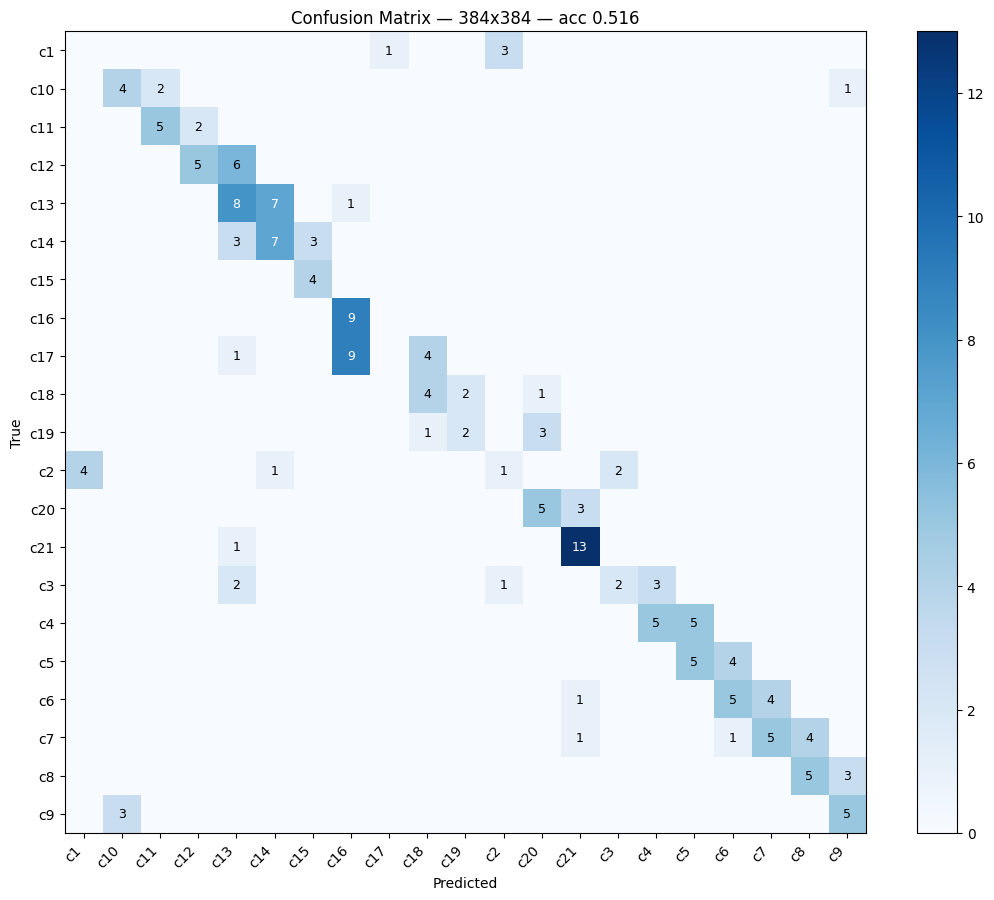

In [9]:
cm = confusion_matrix(y_true, y_pred, labels=range(num_classes))
fig, ax = plt.subplots(figsize=(11, 9))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(num_classes)); ax.set_yticks(range(num_classes))
short_names = [c.replace("class", "c") for c in class_names]
ax.set_xticklabels(short_names, rotation=45, ha="right")
ax.set_yticklabels(short_names)
ax.set_xlabel("Predicted"); ax.set_ylabel("True")
ax.set_title(f"Confusion Matrix — {TARGET_RESOLUTION}x{TARGET_RESOLUTION} — acc {accuracy:.3f}")
for i in range(num_classes):
    for j in range(num_classes):
        if cm[i,j] > 0:
            color = "white" if cm[i,j] > cm.max()/2 else "black"
            ax.text(j, i, cm[i,j], ha="center", va="center", color=color, fontsize=9)
plt.colorbar(im); plt.tight_layout()
plt.savefig(RESULTS_DIR / "confusion_matrix.png", dpi=120, bbox_inches="tight")
plt.show()

## 3.9 Save All Headline Metrics

In [10]:
# Compute total params and approximate model size
total_params = model.count_params()
model_size_mb = (total_params * 4) / (1024 ** 2)  # rough estimate, float32

summary = {
    "resolution": TARGET_RESOLUTION,
    "total_params": int(total_params),
    "model_size_mb": round(model_size_mb, 2),
    "epochs_run": len(history.history["loss"]),
    "total_train_time_sec": round(total_train_time, 1),
    "sec_per_epoch": round(total_train_time / len(history.history["loss"]), 1),
    "inference_ms_per_image": round(per_image_ms, 2),
    "best_val_accuracy": round(float(max(history.history["val_accuracy"])), 4),
    "test_accuracy": round(float(accuracy), 4),
    "macro_f1": round(float(macro_f1), 4),
    "macro_precision": round(float(precision), 4),
    "macro_recall": round(float(recall), 4),
}

with open(RESULTS_DIR / "summary.json", "w") as f:
    json.dump(summary, f, indent=2)

# Save training log
log = pd.DataFrame(history.history)
log["epoch"] = range(1, len(log) + 1)
log.to_csv(RESULTS_DIR / "training_log.csv", index=False)

# Save predictions
preds_df = pd.DataFrame({
    "true": [class_names[i] for i in y_true],
    "predicted": [class_names[i] for i in y_pred],
    "correct": (y_true == y_pred).astype(int),
})
preds_df.to_csv(RESULTS_DIR / "test_predictions.csv", index=False)

print(f"\nAll outputs saved to: {RESULTS_DIR}")
print("\nSummary:")
for k, v in summary.items():
    print(f"  {k}: {v}")


All outputs saved to: /content/drive/MyDrive/VisionProject/res_384

Summary:
  resolution: 384
  total_params: 2284885
  model_size_mb: 8.72
  epochs_run: 15
  total_train_time_sec: 463.9
  sec_per_epoch: 30.9
  inference_ms_per_image: 411.98
  best_val_accuracy: 0.5102
  test_accuracy: 0.5156
  macro_f1: 0.4852
  macro_precision: 0.4813
  macro_recall: 0.5177


---

**Now do the same for other resolutions.** Change `TARGET_RESOLUTION` at the top to 128, rerun all cells. Then to 224. Then to 384. You'll have four populated results folders when done.

**Next step:** Run Notebook 4 (`4_compare_and_visualize.ipynb`) to build the comparison report.